In [9]:
!pip install -q ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

In [10]:
diabetes = fetch_ucirepo(id=296)

X = diabetes.data.features
y = diabetes.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Features shape: (101766, 47)
Target shape: (101766, 1)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes


,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO


In [11]:
print("Dataset information:")
X.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-n

In [12]:
print("\nTarget distribution:")
print(y.value_counts())


Target distribution:
readmitted
NO            54864
>30           35545
<30           11357
Name: count, dtype: int64


In [13]:
y_binary = y["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

print(y_binary.value_counts())

print("\nClass percentages:")
print(y_binary.value_counts(normalize=True) * 100)

readmitted
0    90409
1    11357
Name: count, dtype: int64

Class percentages:
readmitted
0    88.840084
1    11.159916
Name: proportion, dtype: float64


In [14]:
columns_to_drop = [
    "encounter_id",
    "patient_nbr"
]

X = X.drop(columns=columns_to_drop, errors='ignore')

print("New shape:", X.shape)

New shape: (101766, 47)


In [15]:
X = X.drop(columns=["readmitted"], errors="ignore")

In [16]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 11
Number of categorical features: 36

Numerical features:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features:
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 81412
Testing samples: 20354


In [18]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [19]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                max_iter=1000,
                solver="liblinear"
            )
        )
    ]
)

In [20]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [21]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(y_prob[:10])

First 10 predicted probabilities:
[0.14056457 0.06426117 0.09590499 0.25927959 0.11573777 0.03168522
 0.05598201 0.06221841 0.25995923 0.19648574]


In [22]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Performance")
print("-------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Model Performance
-------------------------
Accuracy : 0.8883266188464184
Precision: 0.4883720930232558
Recall   : 0.018494055482166448
F1 Score : 0.03563852354688163
ROC-AUC  : 0.6463616213831553


In [23]:
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "Not readmitted within 30 days",
        "Readmitted within 30 days"
    ]
))

                               precision    recall  f1-score   support

Not readmitted within 30 days       0.89      1.00      0.94     18083
    Readmitted within 30 days       0.49      0.02      0.04      2271

                     accuracy                           0.89     20354
                    macro avg       0.69      0.51      0.49     20354
                 weighted avg       0.85      0.89      0.84     20354



Confusion Matrix:
[[18039    44]
 [ 2229    42]]


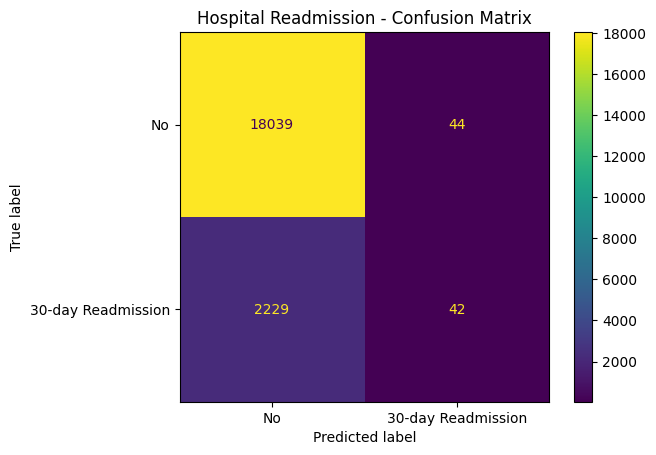

In [24]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "30-day Readmission"]
)

disp.plot()
plt.title("Hospital Readmission - Confusion Matrix")
plt.show()

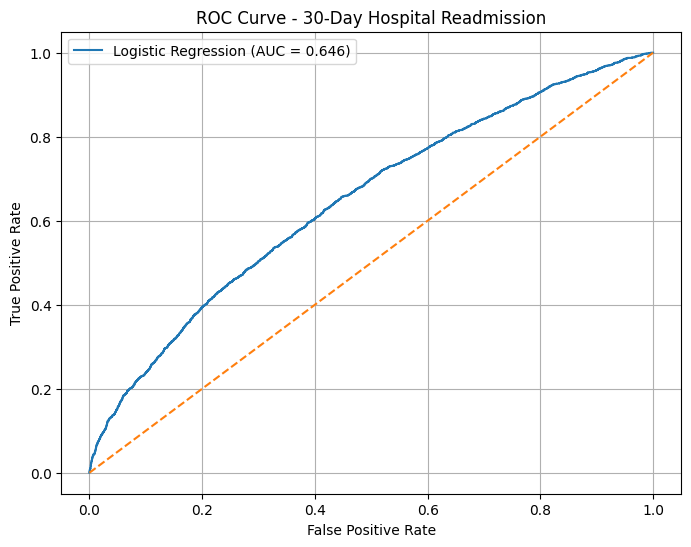

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Hospital Readmission")
plt.legend()
plt.grid()
plt.show()